In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = sns.load_dataset('titanic')
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'
data = df[features + [target]].dropna()
data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)

print("Cleaned shape:", data.shape)
print("Columns:", list(data.columns))
data.head()


Cleaned shape: (712, 9)
Columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


In [4]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=6,random_state=42)
model.fit(X_train, y_train)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 569
Testing  samples : 143


Accuracy: 0.7622



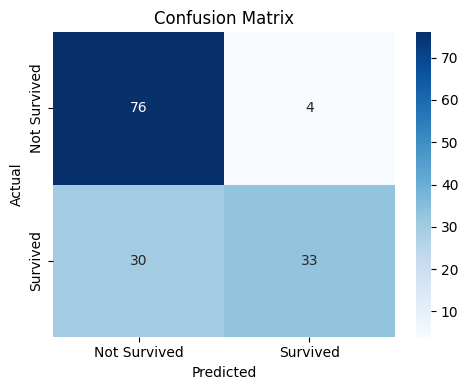

In [5]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
# print("Classification Report:")
# print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

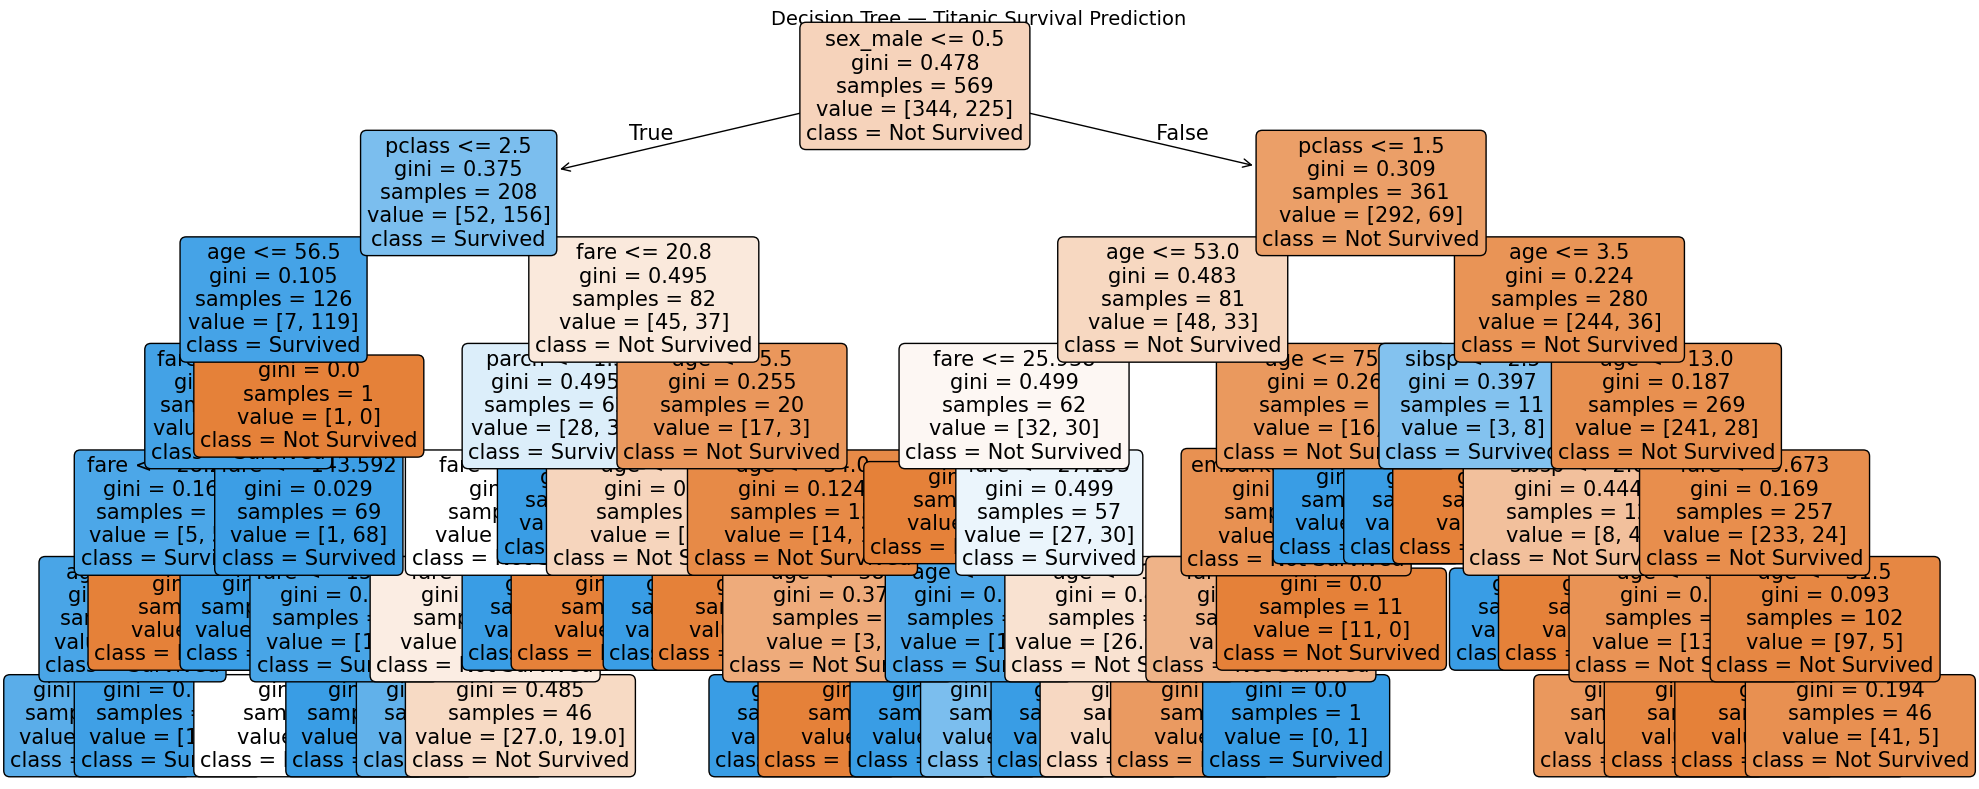

In [6]:
plt.figure(figsize=(20, 8))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=15)
plt.title('Decision Tree — Titanic Survival Prediction', fontsize=14)
plt.tight_layout()
plt.show()

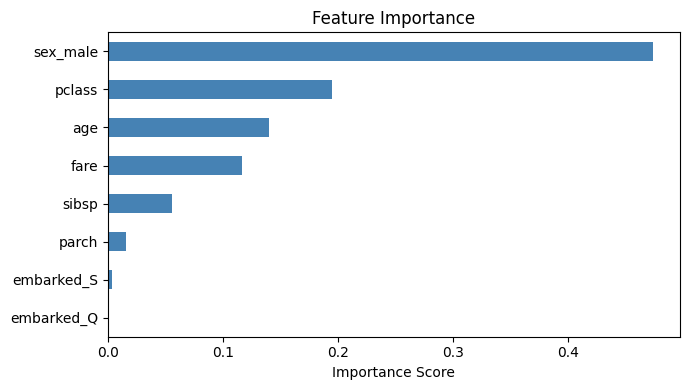

In [7]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING 

Best max_depth : 6
Best Test Accuracy : 0.7622


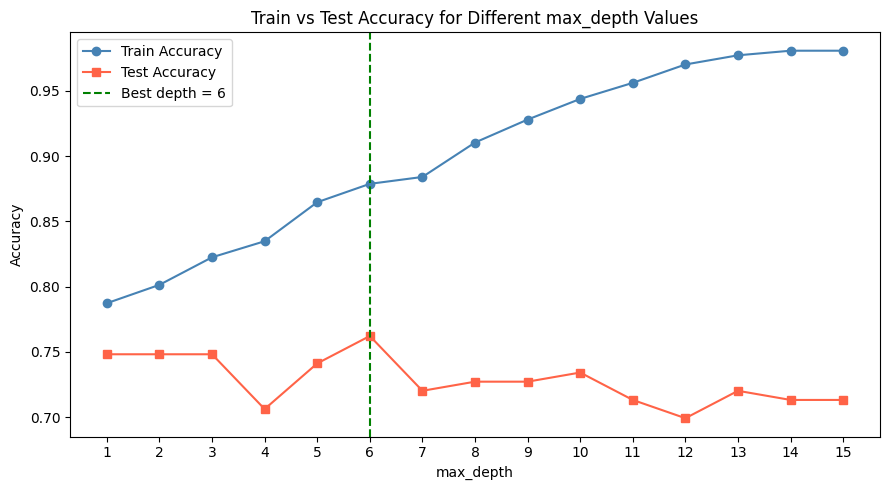

In [8]:
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

# Find best depth
best_depth = depths[test_scores.index(max(test_scores))]
print(f"Best max_depth : {best_depth}")
print(f"Best Test Accuracy : {max(test_scores):.4f}")

# Plot
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_scores,  marker='s', label='Test Accuracy',  color='tomato')
plt.axvline(best_depth, linestyle='--', color='green', label=f'Best depth = {best_depth}')
plt.title('Train vs Test Accuracy for Different max_depth Values')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(list(depths))
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred)   # from original model (max_depth=5)
tuned_acc    = accuracy_score(y_test, best_pred)

print(f"Baseline Accuracy (max_depth=5) : {baseline_acc:.4f}")
print(f"Tuned    Accuracy (max_depth={best_depth}) : {tuned_acc:.4f}")
print(f"Improvement                     : {(tuned_acc - baseline_acc)*100:+.2f}%")


Baseline Accuracy (max_depth=5) : 0.7622
Tuned    Accuracy (max_depth=6) : 0.7622
Improvement                     : +0.00%
